In [1]:
!pip -q install tensorflow hdbscan

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict
from itertools import combinations

import tensorflow as tf

from sklearn.preprocessing import normalize
from sklearn.random_projection import SparseRandomProjection
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score

try:
    import hdbscan
    HDBSCAN_AVAILABLE = True
except Exception as e:
    HDBSCAN_AVAILABLE = False
    print("HDBSCAN not available:", e)

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [2]:
SELECTED_CLASSES = [0, 2, 6, 8]
CLASS_NAMES_ALL = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]
TARGET_NAMES = [CLASS_NAMES_ALL[i] for i in SELECTED_CLASSES]

MAX_PER_CLASS = 2000

(x_train, y_train), (_, _) = tf.keras.datasets.fashion_mnist.load_data()

images = []
y_true = []

class_counts = {c: 0 for c in SELECTED_CLASSES}

for img, label in zip(x_train, y_train):
    label = int(label)

    if label not in SELECTED_CLASSES:
        continue

    if class_counts[label] >= MAX_PER_CLASS:
        continue

    images.append(img.astype(np.float32) / 255.0)
    y_true.append(SELECTED_CLASSES.index(label))
    class_counts[label] += 1

    if all(class_counts[c] >= MAX_PER_CLASS for c in SELECTED_CLASSES):
        break

images = np.array(images, dtype=np.float32)
y_true = np.array(y_true)

print("Images shape:", images.shape)
print("Selected classes:", TARGET_NAMES)
print("Counts:", {TARGET_NAMES[i]: int(np.sum(y_true == i)) for i in range(len(TARGET_NAMES))})

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Images shape: (8000, 28, 28)
Selected classes: ['T-shirt/top', 'Pullover', 'Shirt', 'Bag']
Counts: {'T-shirt/top': 2000, 'Pullover': 2000, 'Shirt': 2000, 'Bag': 2000}


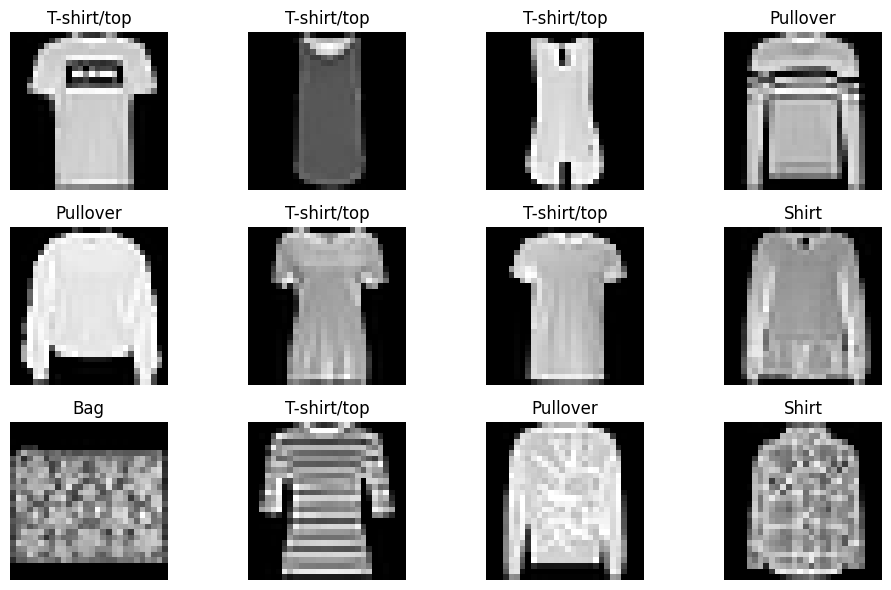

In [3]:
plt.figure(figsize=(10, 6))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i], cmap="gray")
    plt.title(TARGET_NAMES[y_true[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [4]:
def extract_image_features(imgs):
    X = imgs.reshape(len(imgs), -1).astype(np.float32)
    return X

X_feat = extract_image_features(images)
X_feat = normalize(X_feat, norm="l2", axis=1)

print("Feature matrix shape:", X_feat.shape)

Feature matrix shape: (8000, 784)


In [5]:
JL_DIM = 128

rp = SparseRandomProjection(
    n_components=JL_DIM,
    dense_output=True,
    random_state=42
)

t0 = time.perf_counter()
X_jl = rp.fit_transform(X_feat)
jl_time = time.perf_counter() - t0

X_jl = normalize(X_jl, norm="l2", axis=1)

print("JL shape:", X_jl.shape)
print("JL transform time:", jl_time)

JL shape: (8000, 128)
JL transform time: 0.08165595200000553


Mean abs distortion: 0.042411104
95% abs distortion: 0.104773454


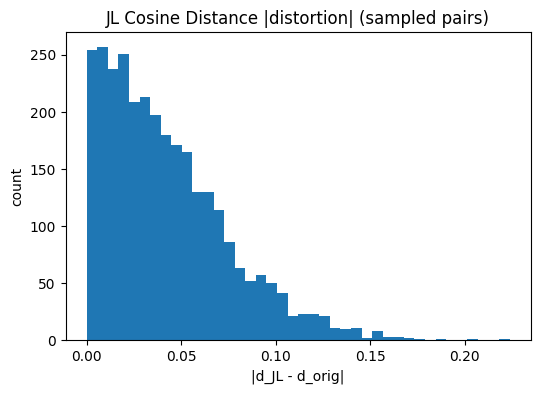

In [6]:
rng = np.random.default_rng(0)
n = X_feat.shape[0]
pairs = 3000

idx_a = rng.integers(0, n, size=pairs)
idx_b = rng.integers(0, n, size=pairs)

orig_sim = np.sum(X_feat[idx_a] * X_feat[idx_b], axis=1)
orig_dist = 1.0 - orig_sim

jl_sim = np.sum(X_jl[idx_a] * X_jl[idx_b], axis=1)
jl_dist = 1.0 - jl_sim

distortion = jl_dist - orig_dist
abs_distortion = np.abs(distortion)

print("Mean abs distortion:", abs_distortion.mean())
print("95% abs distortion:", np.quantile(abs_distortion, 0.95))

plt.figure(figsize=(6, 4))
plt.hist(abs_distortion, bins=40)
plt.title("JL Cosine Distance |distortion| (sampled pairs)")
plt.xlabel("|d_JL - d_orig|")
plt.ylabel("count")
plt.show()

In [7]:
k = len(np.unique(y_true))

t0 = time.perf_counter()
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
y_km = kmeans.fit_predict(X_jl)
km_time = time.perf_counter() - t0

print("KMeans time:", km_time)

KMeans time: 0.5591587889999801


In [8]:
if HDBSCAN_AVAILABLE:
    t0 = time.perf_counter()
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=15,
        min_samples=5,
        metric="euclidean"
    )
    y_hdb = clusterer.fit_predict(X_jl)
    hdb_time = time.perf_counter() - t0

    print("HDBSCAN time:", hdb_time)
    print("HDBSCAN clusters (excluding -1 noise):", len(set(y_hdb)) - (1 if -1 in y_hdb else 0))
else:
    y_hdb = None
    hdb_time = None

HDBSCAN time: 30.86503786999998
HDBSCAN clusters (excluding -1 noise): 6


In [9]:
def random_hyperplane_hash(X, hyperplanes):
    proj = X @ hyperplanes.T
    return proj >= 0.0

def bits_to_int(bit_row):
    out = 0
    for b in bit_row:
        out = (out << 1) | int(b)
    return out

def lsh_candidate_buckets(bits, band_size):
    n, n_bits = bits.shape
    assert n_bits % band_size == 0
    n_bands = n_bits // band_size

    tables = []
    for b in range(n_bands):
        start = b * band_size
        end = start + band_size
        table = defaultdict(list)
        for i in range(n):
            key = bits_to_int(bits[i, start:end])
            table[key].append(i)
        tables.append(table)
    return tables

def build_candidate_pairs(tables, max_bucket_size=200):
    cand = set()
    for table in tables:
        for _, idxs in table.items():
            if len(idxs) < 2:
                continue
            if len(idxs) > max_bucket_size:
                continue
            for i, j in combinations(idxs, 2):
                cand.add((min(i, j), max(i, j)))
    return cand

def connected_components(n, edges):
    parent = np.arange(n)

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra

    for i, j in edges:
        union(i, j)

    roots = np.array([find(i) for i in range(n)])
    _, labels = np.unique(roots, return_inverse=True)
    return labels

In [10]:
N_BITS = 96
BAND_SIZE = 12
COS_THRESHOLD = 0.80
MAX_BUCKET = 250

rng = np.random.default_rng(42)
d = X_jl.shape[1]

hyperplanes = rng.normal(size=(N_BITS, d)).astype(np.float32)
hyperplanes /= np.linalg.norm(hyperplanes, axis=1, keepdims=True) + 1e-12

t0 = time.perf_counter()

bits = random_hyperplane_hash(X_jl, hyperplanes)
tables = lsh_candidate_buckets(bits, band_size=BAND_SIZE)
cand_pairs = build_candidate_pairs(tables, max_bucket_size=MAX_BUCKET)

mid = time.perf_counter()

edges = []
for i, j in cand_pairs:
    sim = float(np.dot(X_jl[i], X_jl[j]))
    if sim >= COS_THRESHOLD:
        edges.append((i, j))

y_lsh = connected_components(n=X_jl.shape[0], edges=edges)

lsh_time = time.perf_counter() - t0
hash_time = mid - t0
refine_time = lsh_time - hash_time

print("LSH candidates:", len(cand_pairs))
print("LSH edges kept:", len(edges))
print("LSH clusters:", len(np.unique(y_lsh)))
print("LSH total time:", lsh_time)
print("Hash time:", hash_time)
print("Refine time:", refine_time)

LSH candidates: 1393005
LSH edges kept: 701940
LSH clusters: 325
LSH total time: 8.568237500999999
Hash time: 1.4944376949999878
Refine time: 7.073799806000011


In [11]:
def purity_score(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    N = len(y_true)
    total = 0
    for c in np.unique(y_pred):
        idx = np.where(y_pred == c)[0]
        if len(idx) == 0:
            continue
        _, counts = np.unique(y_true[idx], return_counts=True)
        total += counts.max()
    return total / N

def safe_silhouette(X, labels):
    labels = np.asarray(labels)
    if len(np.unique(labels)) < 2:
        return np.nan
    return silhouette_score(X, labels, metric="euclidean")

In [12]:
rows = []

rows.append({
    "method": "KMeans (on JL)",
    "time_sec": km_time,
    "ARI": adjusted_rand_score(y_true, y_km),
    "NMI": normalized_mutual_info_score(y_true, y_km),
    "Purity": purity_score(y_true, y_km),
    "Silhouette": safe_silhouette(X_jl, y_km),
    "n_clusters": len(np.unique(y_km))
})

if HDBSCAN_AVAILABLE and y_hdb is not None:
    y_hdb_non_noise = y_hdb[y_hdb != -1]
    X_hdb_non_noise = X_jl[y_hdb != -1]

    sil = np.nan
    if len(y_hdb_non_noise) > 1 and len(np.unique(y_hdb_non_noise)) >= 2:
        sil = silhouette_score(X_hdb_non_noise, y_hdb_non_noise, metric="euclidean")

    rows.append({
        "method": "HDBSCAN (on JL)",
        "time_sec": hdb_time,
        "ARI": adjusted_rand_score(y_true, y_hdb),
        "NMI": normalized_mutual_info_score(y_true, y_hdb),
        "Purity": purity_score(y_true, y_hdb),
        "Silhouette": sil,
        "n_clusters": len(set(y_hdb)) - (1 if -1 in y_hdb else 0)
    })

rows.append({
    "method": "JL + Random-Hyperplane LSH (custom)",
    "time_sec": lsh_time,
    "ARI": adjusted_rand_score(y_true, y_lsh),
    "NMI": normalized_mutual_info_score(y_true, y_lsh),
    "Purity": purity_score(y_true, y_lsh),
    "Silhouette": safe_silhouette(X_jl, y_lsh),
    "n_clusters": len(np.unique(y_lsh))
})

results = pd.DataFrame(rows).sort_values("time_sec")
results

,method,time_sec,ARI,NMI,Purity,Silhouette,n_clusters
0,KMeans (on JL),0.559159,0.445783,0.514301,0.703625,0.188980,4
2,JL + Random-Hyperplane LSH (custom),8.568238,0.000125,0.063313,0.284000,-0.238220,325
1,HDBSCAN (on JL),30.865038,0.064374,0.236019,0.432250,0.286761,6


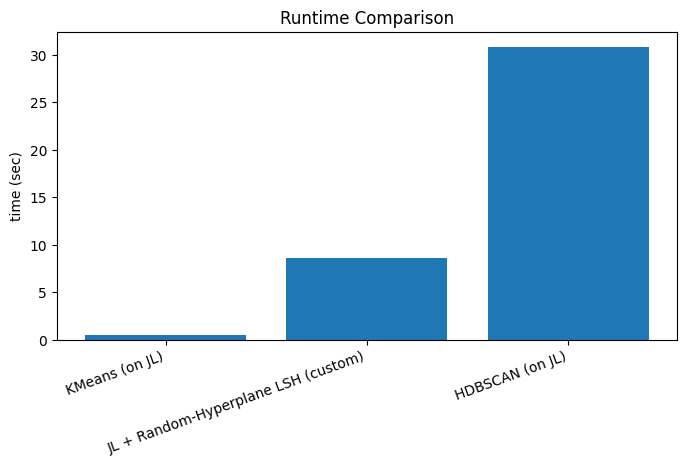

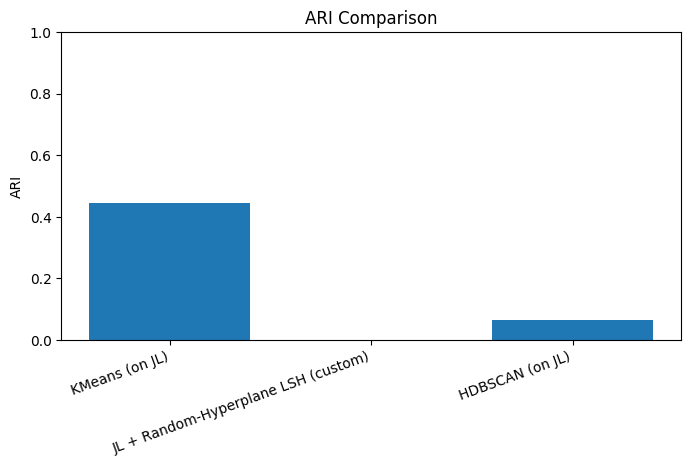

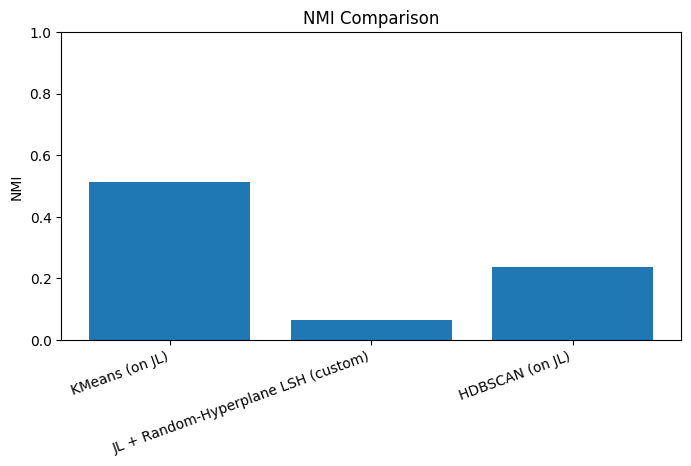

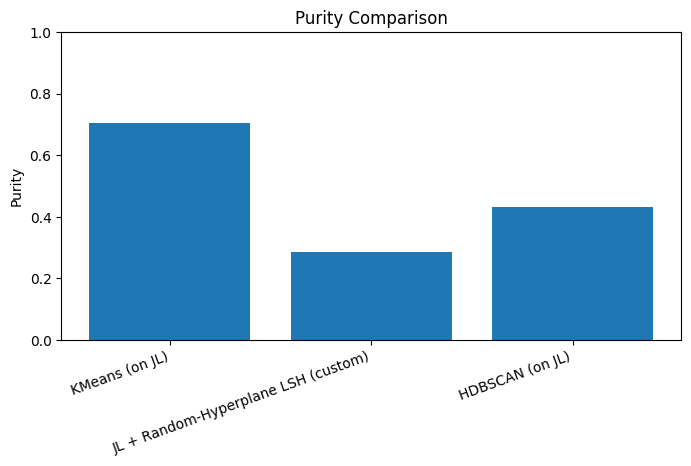

In [13]:
plt.figure(figsize=(8, 4))
plt.bar(results["method"], results["time_sec"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("time (sec)")
plt.title("Runtime Comparison")
plt.show()

for metric in ["ARI", "NMI", "Purity"]:
    plt.figure(figsize=(8, 4))
    plt.bar(results["method"], results[metric])
    plt.xticks(rotation=20, ha="right")
    plt.ylabel(metric)
    plt.title(f"{metric} Comparison")
    plt.ylim(0, 1.0)
    plt.show()

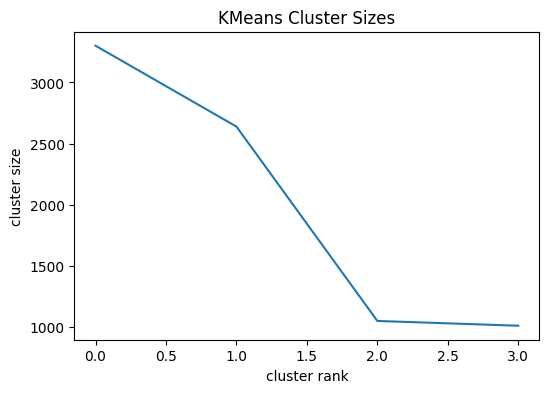

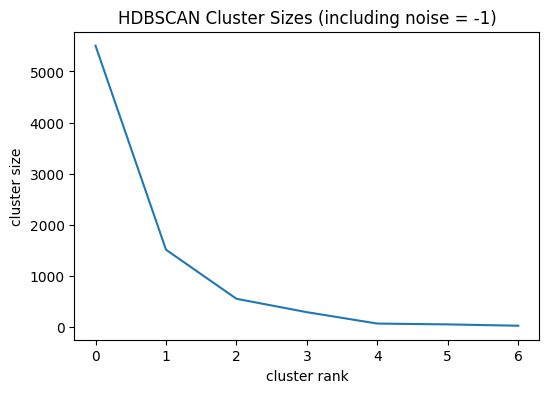

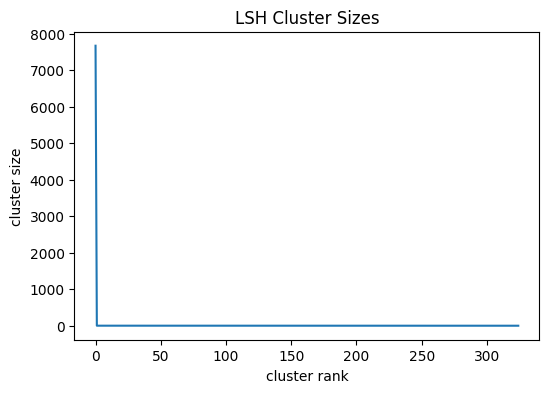

In [14]:
def plot_cluster_sizes(labels, title):
    _, counts = np.unique(labels, return_counts=True)
    counts = np.sort(counts)[::-1]
    plt.figure(figsize=(6, 4))
    plt.plot(counts)
    plt.xlabel("cluster rank")
    plt.ylabel("cluster size")
    plt.title(title)
    plt.show()

plot_cluster_sizes(y_km, "KMeans Cluster Sizes")

if HDBSCAN_AVAILABLE and y_hdb is not None:
    plot_cluster_sizes(y_hdb, "HDBSCAN Cluster Sizes (including noise = -1)")

plot_cluster_sizes(y_lsh, "LSH Cluster Sizes")

In [15]:
def augment_image(img, shift_x=2, shift_y=1, noise_std=0.03, brightness=0.05, seed=0):
    rng = np.random.default_rng(seed)

    out = np.roll(img, shift=shift_x, axis=1)
    out = np.roll(out, shift=shift_y, axis=0)

    noise = rng.normal(0, noise_std, size=out.shape).astype(np.float32)
    out = out + noise + brightness
    out = np.clip(out, 0.0, 1.0)

    return out.astype(np.float32)

dup_count = 120
rng = np.random.default_rng(123)
base_idx = rng.choice(len(images), size=dup_count, replace=False)

dup_images = [
    augment_image(images[i], shift_x=2, shift_y=1, noise_std=0.03, brightness=0.03, seed=int(i))
    for i in base_idx
]

aug_images = np.concatenate([images, np.array(dup_images, dtype=np.float32)], axis=0)

N0 = len(images)
dup_pairs = [(int(i), N0 + k) for k, i in enumerate(base_idx)]

print("Original images:", len(images))
print("Augmented images:", len(aug_images))
print("Duplicate pairs:", len(dup_pairs))

Original images: 8000
Augmented images: 8120
Duplicate pairs: 120


In [16]:
X_aug = extract_image_features(aug_images)
X_aug = normalize(X_aug, norm="l2", axis=1)

X_aug_jl = rp.fit_transform(X_aug)
X_aug_jl = normalize(X_aug_jl, norm="l2", axis=1)

t0 = time.perf_counter()

bits_aug = random_hyperplane_hash(X_aug_jl, hyperplanes)
tables_aug = lsh_candidate_buckets(bits_aug, band_size=BAND_SIZE)
cand_aug = build_candidate_pairs(tables_aug, max_bucket_size=MAX_BUCKET)

edges_aug = []
for i, j in cand_aug:
    if float(np.dot(X_aug_jl[i], X_aug_jl[j])) >= COS_THRESHOLD:
        edges_aug.append((i, j))

labels_aug = connected_components(n=X_aug_jl.shape[0], edges=edges_aug)
dup_time = time.perf_counter() - t0

hits = sum(1 for a, b in dup_pairs if labels_aug[a] == labels_aug[b])
dup_recall = hits / len(dup_pairs)

print("Duplicate recall (LSH components):", dup_recall)
print("Time on augmented dataset:", dup_time)

Duplicate recall (LSH components): 0.8416666666666667
Time on augmented dataset: 8.649591002000022


In [17]:
results.to_csv("experiment6_fashion_mnist_results.csv", index=False)
print("Saved: experiment6_fashion_mnist_results.csv")
print(results)

Saved: experiment6_fashion_mnist_results.csv
                                method   time_sec       ARI       NMI  \
0                       KMeans (on JL)   0.559159  0.445783  0.514301   
2  JL + Random-Hyperplane LSH (custom)   8.568238  0.000125  0.063313   
1                      HDBSCAN (on JL)  30.865038  0.064374  0.236019   

     Purity  Silhouette  n_clusters  
0  0.703625    0.188980           4  
2  0.284000   -0.238220         325  
1  0.432250    0.286761           6  


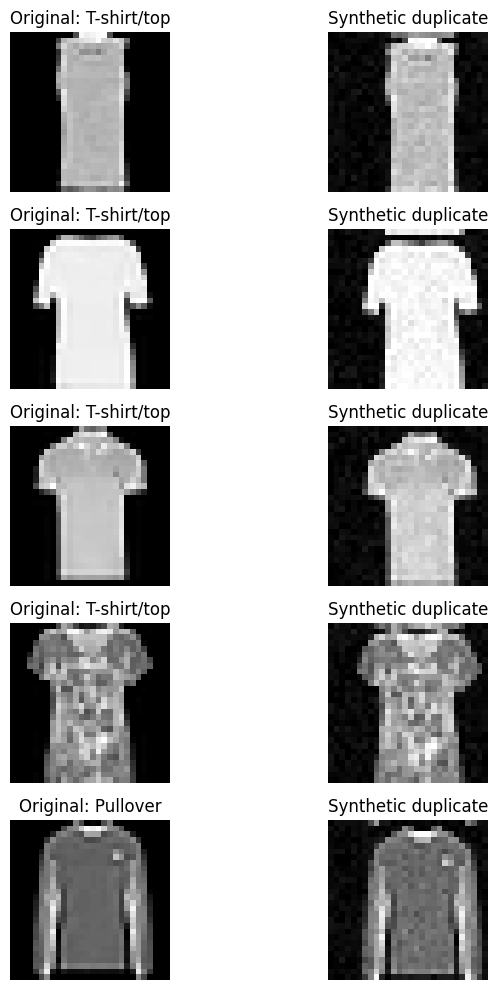

In [18]:
plt.figure(figsize=(8, 10))
for k in range(5):
    idx = base_idx[k]
    dup_idx = N0 + k

    plt.subplot(5, 2, 2*k + 1)
    plt.imshow(images[idx], cmap="gray")
    plt.title(f"Original: {TARGET_NAMES[y_true[idx]]}")
    plt.axis("off")

    plt.subplot(5, 2, 2*k + 2)
    plt.imshow(aug_images[dup_idx], cmap="gray")
    plt.title("Synthetic duplicate")
    plt.axis("off")

plt.tight_layout()
plt.show()